# Annual Instagram Digital Wellness Analysis



*The primary objective of this notebook is to investigate the relationship between Instagram usage patterns and the mental or physical well-being of users. By leveraging data-driven insights, the Digital Wellness Team aims to identify how time spent on the platform correlates with key health indicators to promote a more balanced and healthy user experience.*


*Instagram's Digital Wellness Team consisting of Data and Social Media Analysts collaborated on the data and coding in this report.*

## **Imports & Data Loading**

In [77]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
# Load dataset

df = pd.read_csv(r"C:\Users\mia62\OneDrive\Desktop\IOD\archive\instagram_usage_lifestyle.csv")

df.head(4)

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94


**Listed Column Names & Index**

In [79]:
# To take note of all column names along with their proper Index, copy and paste when needed....


> 0:'user_id',   1:'app_name',   2:'age',   3:'gender',   4:'country',   5:'urban_rural',  6:'income_level',   7:'employment_status',   8:'education_level',   9:'relationship_status', 10:'has_children',   11:'exercise_hours_per_week',   12:'sleep_hours_per_night',   13:'diet_quality', 14:'smoking',   15:'alcohol_frequency',   16:'perceived_stress_score',   17:'self_reported_happiness', 18:'body_mass_index',   19:'blood_pressure_systolic',   20:'blood_pressure_diastolic', 21:'daily_steps_count',   22:'weekly_work_hours',   23:'hobbies_count',   24:'social_events_per_month', 25:'books_read_per_year',   26:'volunteer_hours_per_month',   27:'travel_frequency_per_year', 28:'daily_active_minutes_instagram',   29:'sessions_per_day',   30:'posts_created_per_week', 31:'reels_watched_per_day',   32:'stories_viewed_per_day',   33:'likes_given_per_day', 34:'comments_written_per_day',   35:'dms_sent_per_week',   36:'dms_received_per_week', 37:'ads_viewed_per_day',   38:'ads_clicked_per_day',   39:'time_on_feed_per_day', 40:'time_on_explore_per_day',   41:'time_on_messages_per_day',   42:'time_on_reels_per_day', 43:'followers_count',   44:'following_count',   45:'uses_premium_features', 46:'notification_response_rate',   47:'account_creation_year',   48:'last_login_date', 49:'average_session_length_minutes',   50:'content_type_preference',   51:'preferred_content_theme', 52:'privacy_setting_level',   53:'two_factor_auth_enabled', 54:'biometric_login_used', 55:'linked_accounts_count',   56:'subscription_status',   57:'user_engagement_score'

## **Digital Wellness Demographic Focus**

> Keeping in mind the 'SMART' business problem, we need to create a SPECIFIC demographic to focus on for this analysis. 

### Target Age Group

In [80]:
ig_age = (df["age"] >= 20) & (df["age"] <= 35)

### Geographic Focus

In [81]:
ig_us = df["country"] == "United States"

In [82]:
# Create a single variable for full Dempgraphic Focus....
combined_mask = ig_age & ig_us

### User Segmentation

> **Active Users:** *Individuals spending 200 minutes or more daily on Instagram.*

> **Moderate Users:** *Individuals spending less than 200 minutes daily on Instagram.*

In [83]:
active_ig = df["daily_active_minutes_instagram"] >= 200

In [84]:
inactive_ig = df["daily_active_minutes_instagram"] < 200

### Additional Filters

 **.LOC Filters**

In [85]:
# Where demographic criteria is met...
filtered_data = df.loc[combined_mask]

In [86]:
# Where demographic & active user segmentation criteria is met...
active_filtered = df.loc[combined_mask & active_ig]

In [87]:
# Where demographic & moderate user segmentation criteria is met...
inactive_filtered = df.loc[combined_mask & inactive_ig]

## **Data Exploration & Visualizations**

### Active User Distribution

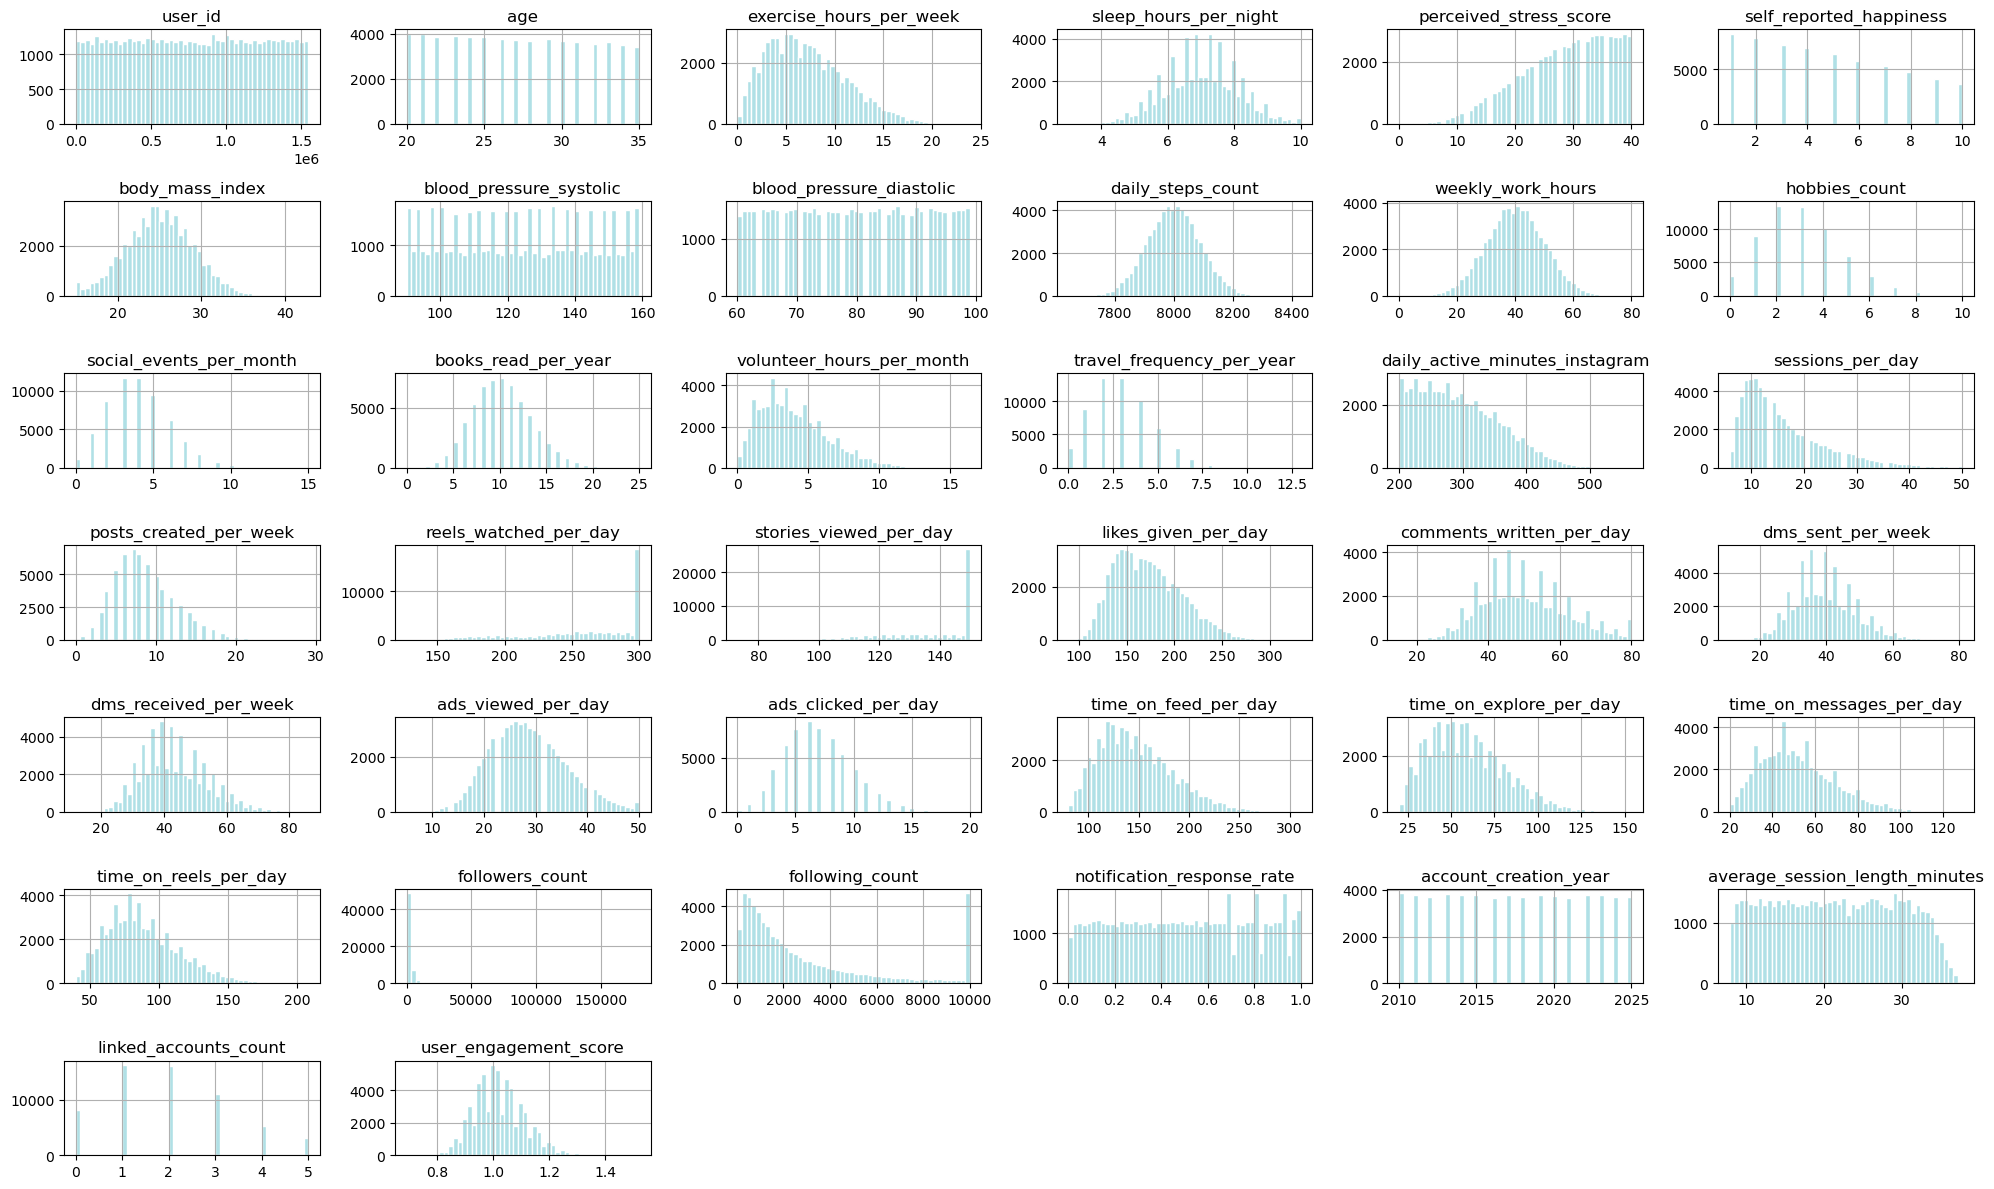

In [88]:
# HISTOGRAM OF ALL
active_filtered.hist(bins=50, figsize=(20, 12), color='powderblue', edgecolor='white')

plt.tight_layout()
plt.show()

### Inactive User Distribution

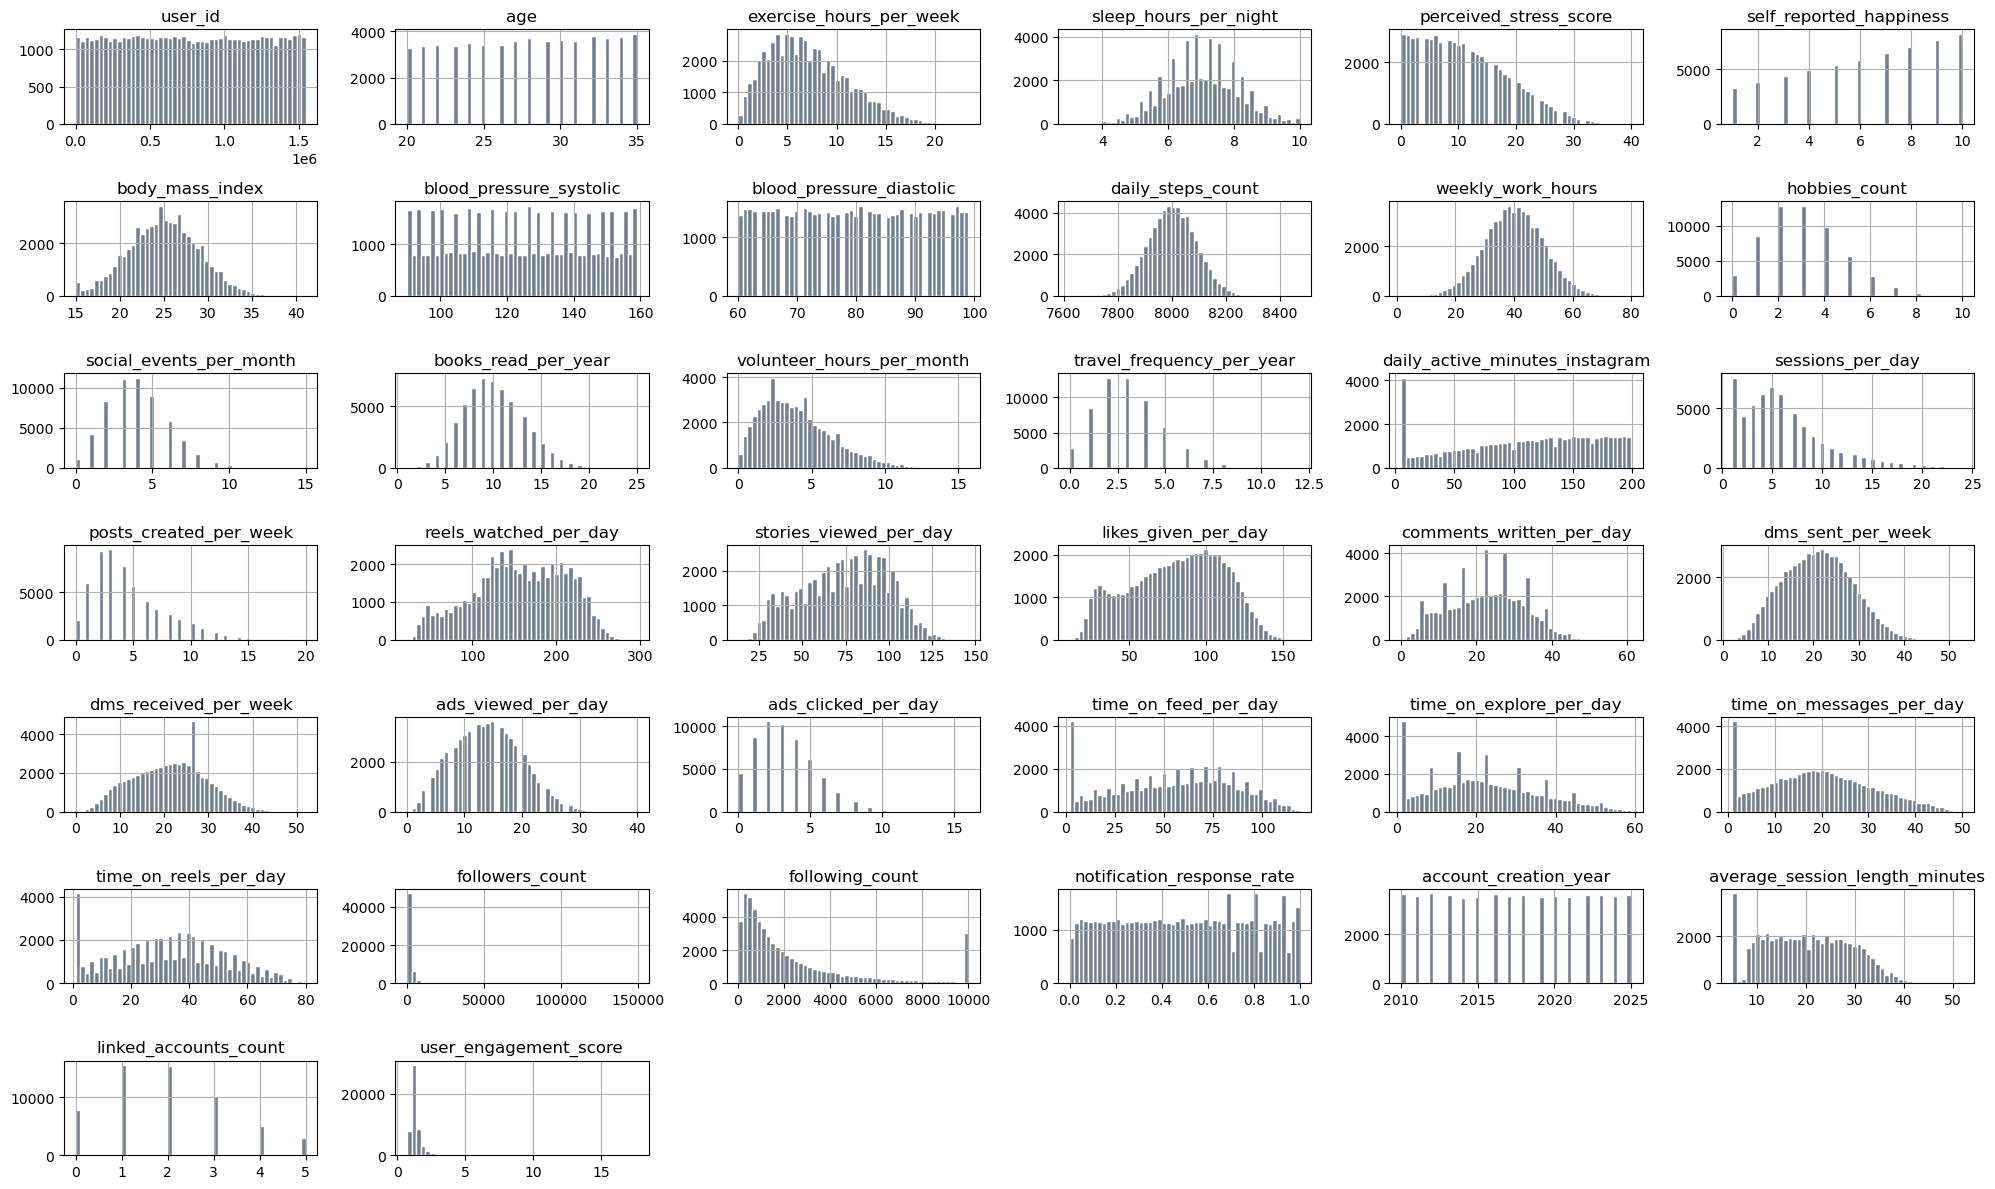

In [89]:
# HISTOGRAM OF ALL
inactive_filtered.hist(bins=50, figsize=(20, 12), color='slategrey', edgecolor='white')

plt.tight_layout()
plt.show()

### Mental Health Data Frame

In [93]:
# Health columns which communicate any important trends...
mental_health = [ 'sleep_hours_per_night', 'perceived_stress_score', 'self_reported_happiness',
            'blood_pressure_systolic', 'blood_pressure_diastolic', 'body_mass_index', 
            'daily_active_minutes_instagram', 'user_engagement_score'
]

In [94]:
# Creating a new dataframe which focuses on relevant columns...
mental_df = df.loc[combined_mask, mental_health]

mental_df.head(4)

,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,blood_pressure_systolic,blood_pressure_diastolic,body_mass_index,daily_active_minutes_instagram,user_engagement_score
5,5.8,1,3,138,71,25.7,49.0,1.64
9,6.5,25,10,128,75,23.3,196.0,1.02
11,7.5,15,7,149,74,21.4,123.0,1.20
26,7.9,30,8,143,64,20.4,224.0,1.05


In [92]:
# For active Instagram users (within the US 20-35 group)
active_mean = mental_df.loc[active_ig].mean()

print("Mean for Active Users:")
display(active_mean)

Mean for Active Users:


sleep_hours_per_night               6.995428
perceived_stress_score             28.731808
self_reported_happiness             4.785377
blood_pressure_systolic           124.431185
blood_pressure_diastolic           79.545707
body_mass_index                    25.004169
daily_active_minutes_instagram    293.896623
user_engagement_score               1.019815
dtype: float64

In [95]:
# For inactive Instagram users (within the US 20-35 group)
inactive_mean = mental_df.loc[inactive_ig].mean()

print("Mean for Inactive Users:")
display(inactive_mean)

Mean for Inactive Users:


sleep_hours_per_night               7.000540
perceived_stress_score             10.856978
self_reported_happiness             6.284768
blood_pressure_systolic           124.415655
blood_pressure_diastolic           79.490401
body_mass_index                    24.994816
daily_active_minutes_instagram    110.433769
user_engagement_score               1.933493
dtype: float64

In [10]:
# Calculate totals by combining the masks
total_active = (combined_mask & active_ig).sum()
total_inactive = (combined_mask & inactive_ig).sum()

print(f"Total Active Users: {total_active}")
print(f"Total Inactive Users: {total_inactive}")

Total Active Users: 59849
Total Inactive Users: 57194


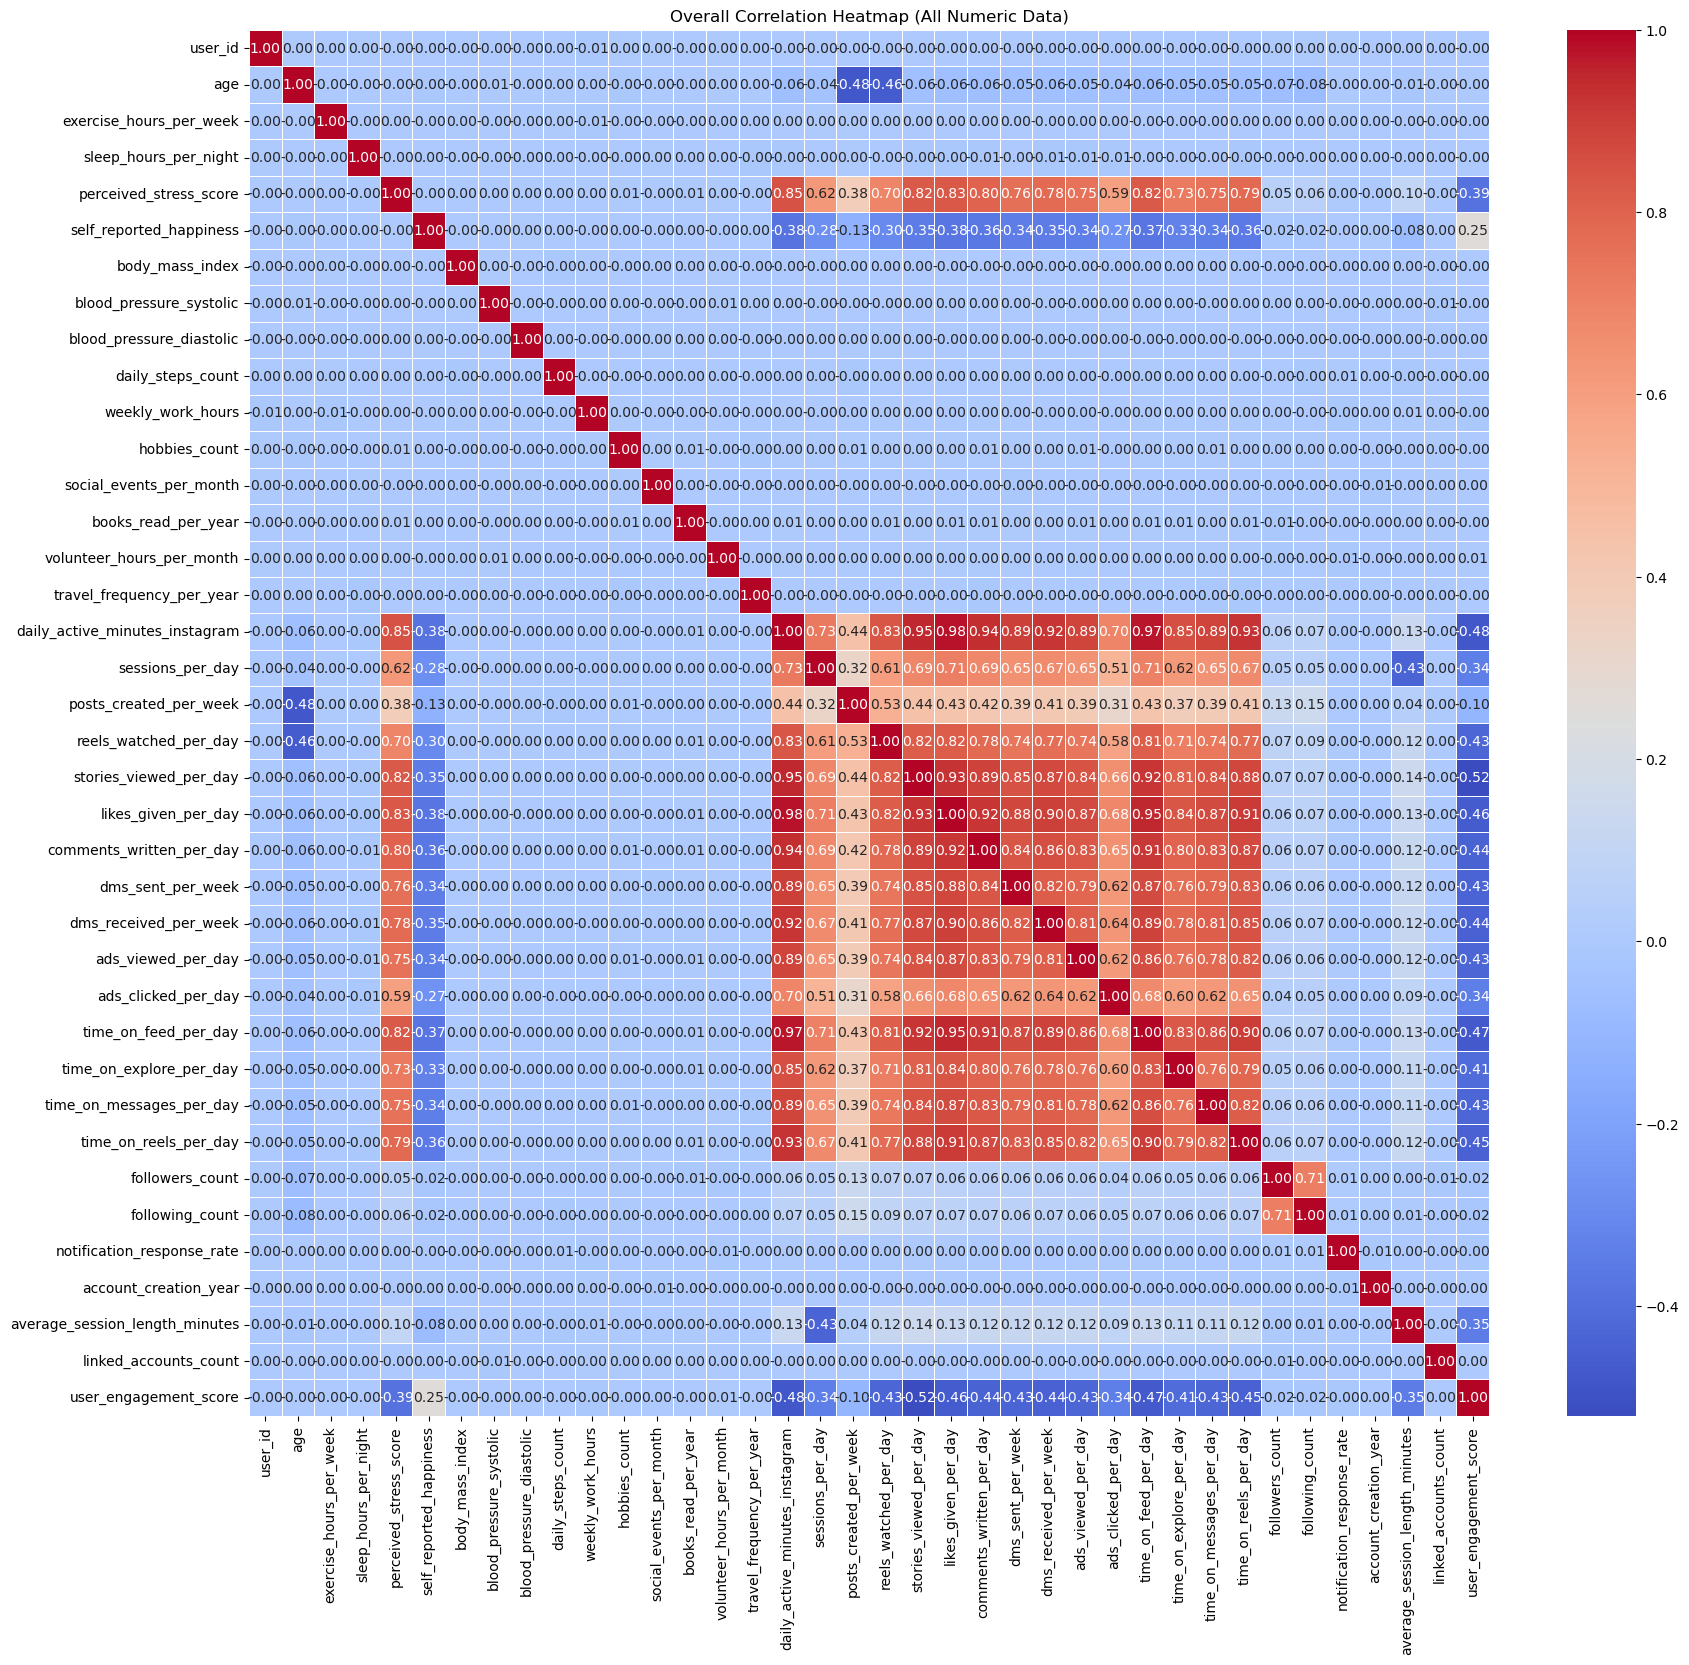

In [96]:
# 1. Filter the original dataframe using your combined_mask
# 2. Use .select_dtypes to automatically pick only the number columns
corr_matrix = df.loc[combined_mask].select_dtypes(include=[np.number]).corr()

# 3. Create the heatmap as before
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Overall Correlation Heatmap (All Numeric Data)')
plt.show()

## **Perceived Stress Scores Data**

### Line Plot

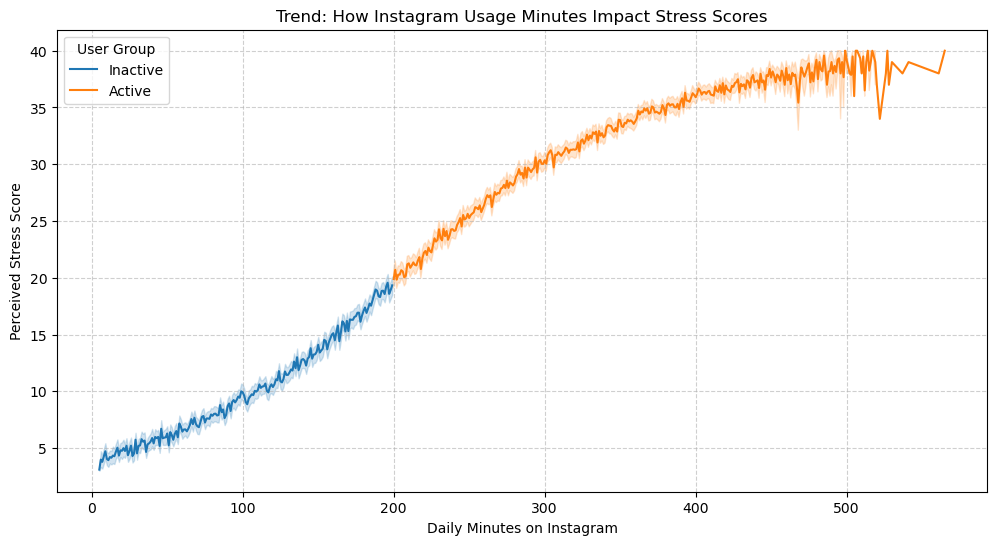

In [12]:
# 1. Add the "Group" label to your mental_df for easier plotting
mental_df['User_Type'] = 'Inactive'
mental_df.loc[active_ig, 'User_Type'] = 'Active'

# 2. Create the Line Graph
plt.figure(figsize=(12, 6))

# Define the plot
ax = sns.lineplot(data=mental_df, x='daily_active_minutes_instagram', y='perceived_stress_score', hue='User_Type')

# --- MAKE BACKGROUND TRANSLUCENT ---
# Set the alpha (0 is transparent, 1 is opaque)
# This affects the area behind the lines
ax.patch.set_alpha(0.3)

plt.title('Trend: How Instagram Usage Minutes Impact Stress Scores')
plt.xlabel('Daily Minutes on Instagram')
plt.ylabel('Perceived Stress Score')
plt.legend(title='User Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(' ', transparent=True)

plt.show()

# # Save with a transparent background and high resolution
# plt.savefig('instagram_stress_trend.png', transparent=True, dpi=300, bbox_inches='tight')

# plt.show()

### Scatter Plot

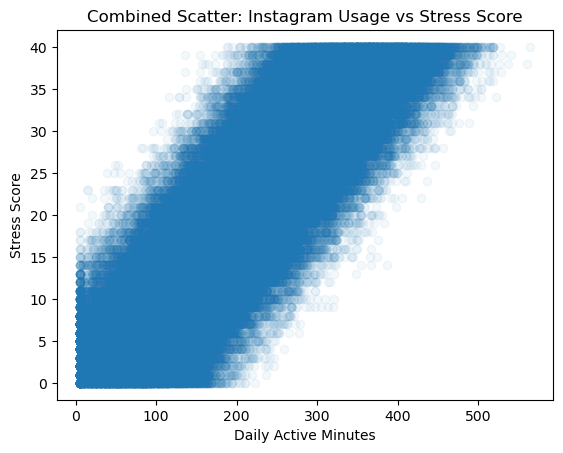

In [58]:
# --- SCATTER PLOT: COMBINED USER SEGMENTATION ---
plt.scatter(filtered_data["daily_active_minutes_instagram"], 
            filtered_data["perceived_stress_score"], 
            alpha=0.05)

# Add labels and title
plt.title('Combined Scatter: Instagram Usage vs Stress Score')
plt.xlabel('Daily Active Minutes')
plt.ylabel('Stress Score')
plt.show()

### Histogram

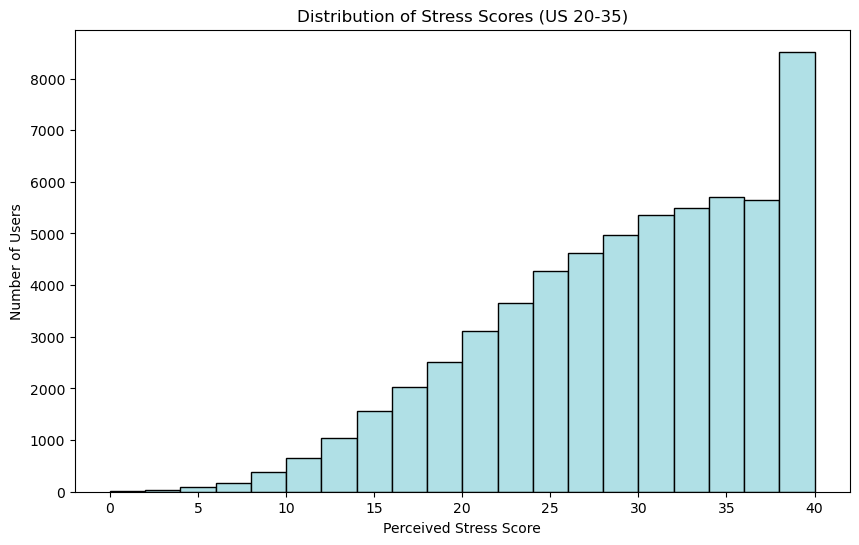

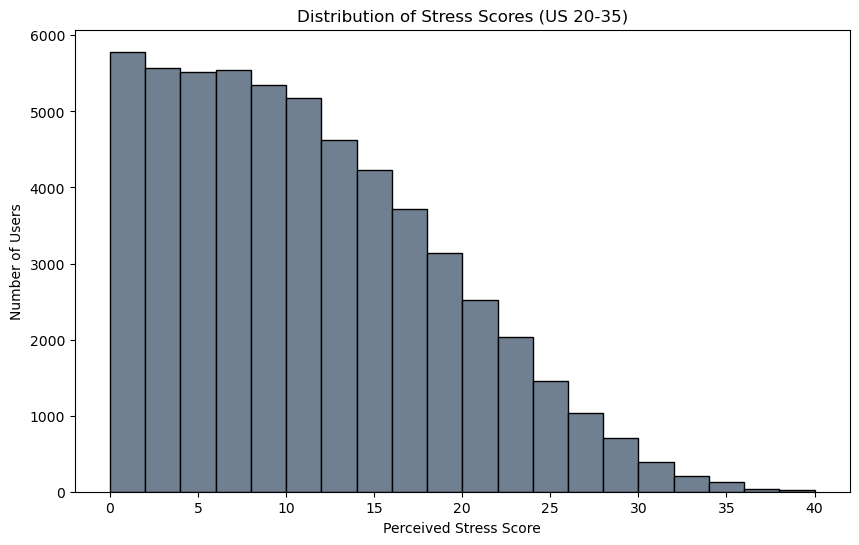

In [59]:
# --- HISTOGRAM COMPARISON ---


# --- ACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(active_filtered['perceived_stress_score'], bins=20, color='powderblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Stress Scores (US 20-35)')
plt.xlabel('Perceived Stress Score')
plt.ylabel('Number of Users')
plt.show()

# --- INACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(inactive_filtered['perceived_stress_score'], bins=20, color='slategrey', edgecolor='black')

# Add labels and title
plt.title('Distribution of Stress Scores (US 20-35)')
plt.xlabel('Perceived Stress Score')
plt.ylabel('Number of Users')
plt.show()


## **Self Reported Happiness Data**

### Line Plot

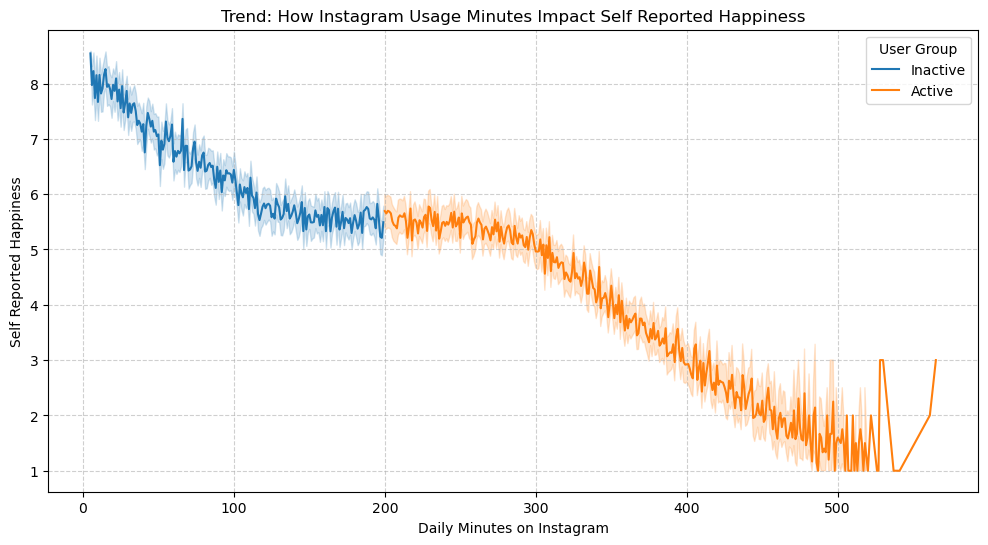

In [27]:
# 1. Add the "Group" label to your mental_df for easier plotting
mental_df['User_Type'] = 'Inactive'
mental_df.loc[active_ig, 'User_Type'] = 'Active'

# 2. Create the Line Graph
plt.figure(figsize=(12, 6))

# Define the plot
ax = sns.lineplot(data=mental_df, x='daily_active_minutes_instagram', y='self_reported_happiness', hue='User_Type')

# --- MAKE BACKGROUND TRANSLUCENT ---
# Set the alpha (0 is transparent, 1 is opaque)
# This affects the area behind the lines
ax.patch.set_alpha(0.3)

plt.title('Trend: How Instagram Usage Minutes Impact Self Reported Happiness')
plt.xlabel('Daily Minutes on Instagram')
plt.ylabel('Self Reported Happiness')
plt.legend(title='User Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(' ', transparent=True)

plt.show()

# # Save with a transparent background and high resolution
# plt.savefig('instagram_stress_trend.png', transparent=True, dpi=300, bbox_inches='tight')

# plt.show()

### Scatter Plot

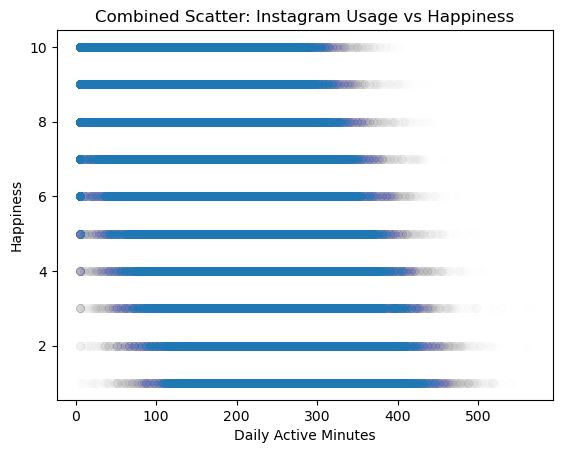

In [154]:
# COMBINED SCATTER GRAPH
plt.scatter(filtered_data["daily_active_minutes_instagram"], 
            filtered_data["self_reported_happiness"], 
            alpha=0.003)

plt.title('Combined Scatter: Instagram Usage vs Happiness')
plt.xlabel('Daily Active Minutes')
plt.ylabel('Happiness')
plt.show()

### Histogram

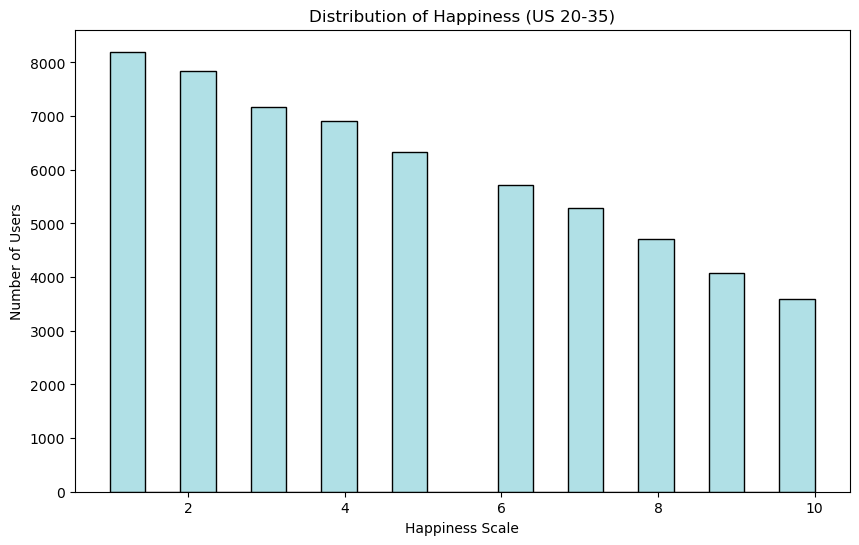

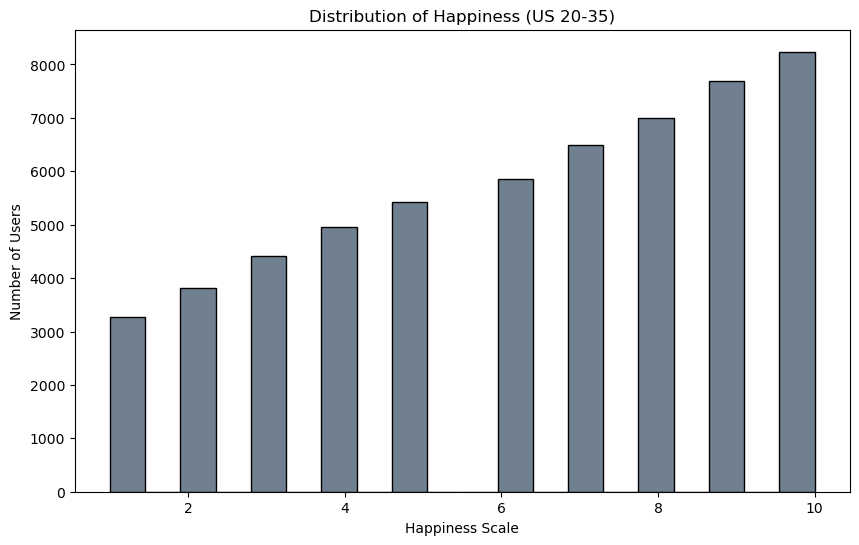

In [160]:
# --- ACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(active_filtered['self_reported_happiness'], bins=20, color='powderblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of Happiness (US 20-35)')
plt.xlabel('Happiness Scale')
plt.ylabel('Number of Users')
plt.show()

# --- INACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(inactive_filtered['self_reported_happiness'], bins=20, color='slategrey', edgecolor='black')

# Add labels and title
plt.title('Distribution of Happiness (US 20-35)')
plt.xlabel('Happiness Scale')
plt.ylabel('Number of Users')
plt.show()

## **User Engagement Score Data**

### Line Plot

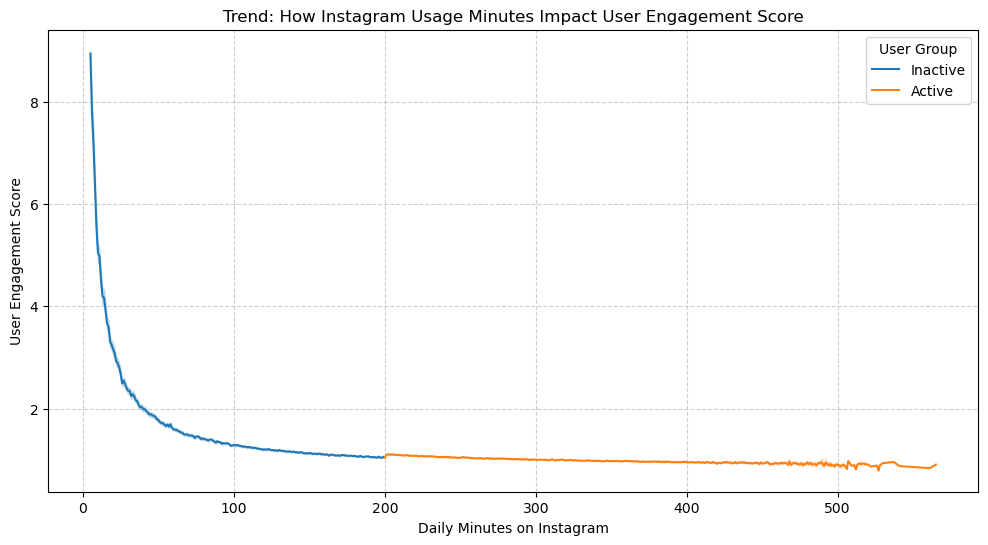

In [30]:
# 1. Add the "Group" label to your mental_df for easier plotting
mental_df['User_Type'] = 'Inactive'
mental_df.loc[active_ig, 'User_Type'] = 'Active'

# 2. Create the Line Graph
plt.figure(figsize=(12, 6))

# Define the plot
ax = sns.lineplot(data=mental_df, x='daily_active_minutes_instagram', y='user_engagement_score', hue='User_Type')

# --- MAKE BACKGROUND TRANSLUCENT ---
# Set the alpha (0 is transparent, 1 is opaque)
# This affects the area behind the lines
ax.patch.set_alpha(0.3)

plt.title('Trend: How Instagram Usage Minutes Impact User Engagement Score')
plt.xlabel('Daily Minutes on Instagram')
plt.ylabel('User Engagement Score')
plt.legend(title='User Group')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig(' ', transparent=True)

plt.show()

# # Save with a transparent background and high resolution
# plt.savefig('instagram_stress_trend.png', transparent=True, dpi=300, bbox_inches='tight')

# plt.show()

### Scatter Plot

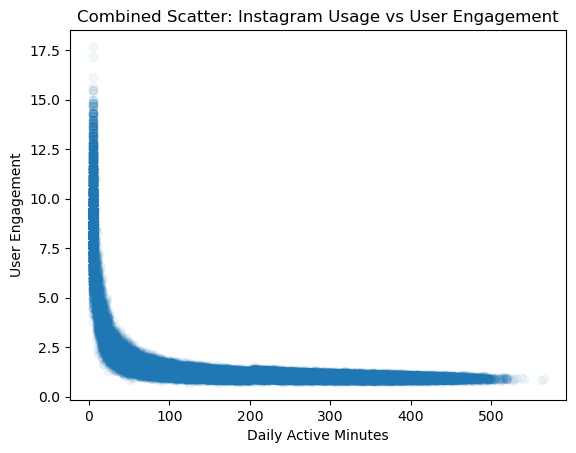

In [74]:
# COMBINED SCATTER GRAPH
plt.scatter(filtered_data["daily_active_minutes_instagram"], 
            filtered_data["user_engagement_score"], 
            alpha=0.05)

plt.title('Combined Scatter: Instagram Usage vs User Engagement')
plt.xlabel('Daily Active Minutes')
plt.ylabel('User Engagement')
plt.show()

### Histogram

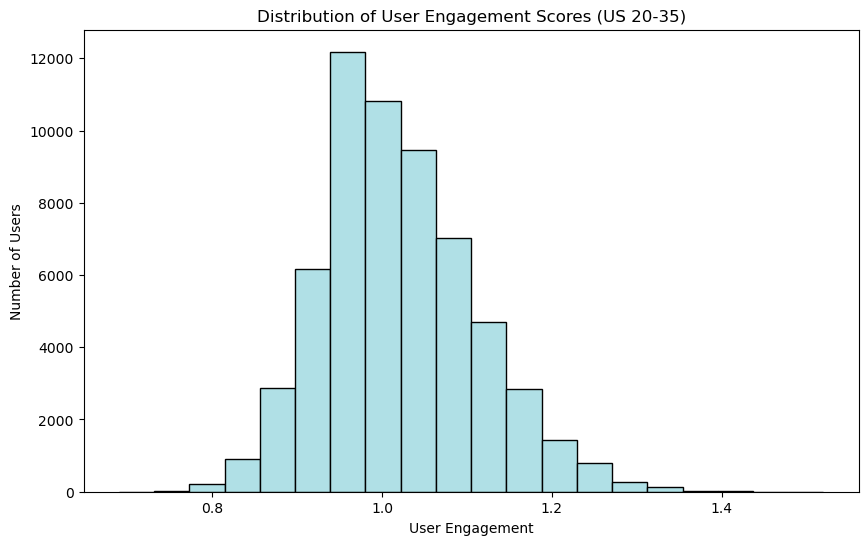

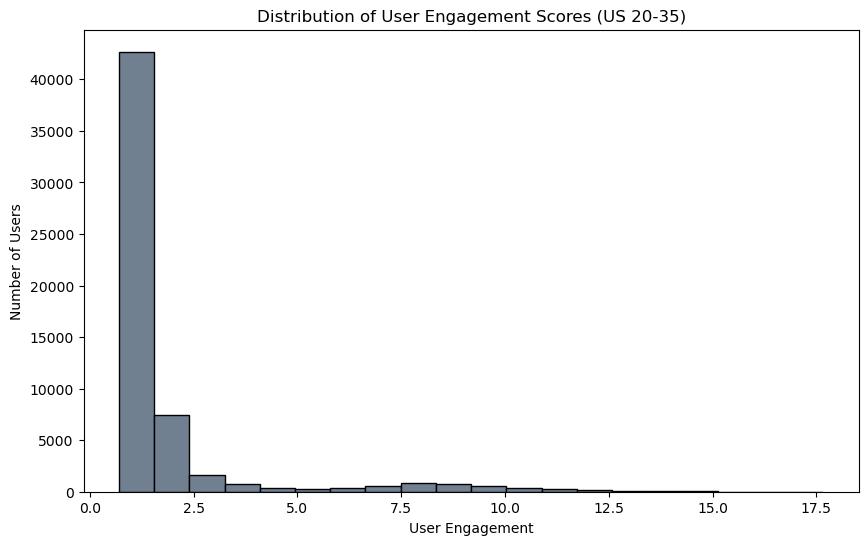

In [161]:
# --- ACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(active_filtered['user_engagement_score'], bins=20, color='powderblue', edgecolor='black')

# Add labels and title
plt.title('Distribution of User Engagement Scores (US 20-35)')
plt.xlabel('User Engagement')
plt.ylabel('Number of Users')
plt.show()

# --- INACTIVE HISTOGRAM ---
plt.figure(figsize=(10, 6))
plt.hist(inactive_filtered['user_engagement_score'], bins=20, color='slategrey', edgecolor='black')

# Add labels and title
plt.title('Distribution of User Engagement Scores (US 20-35)')
plt.xlabel('User Engagement')
plt.ylabel('Number of Users')
plt.show()

## **Conclusion**

### Correlated Heatmap

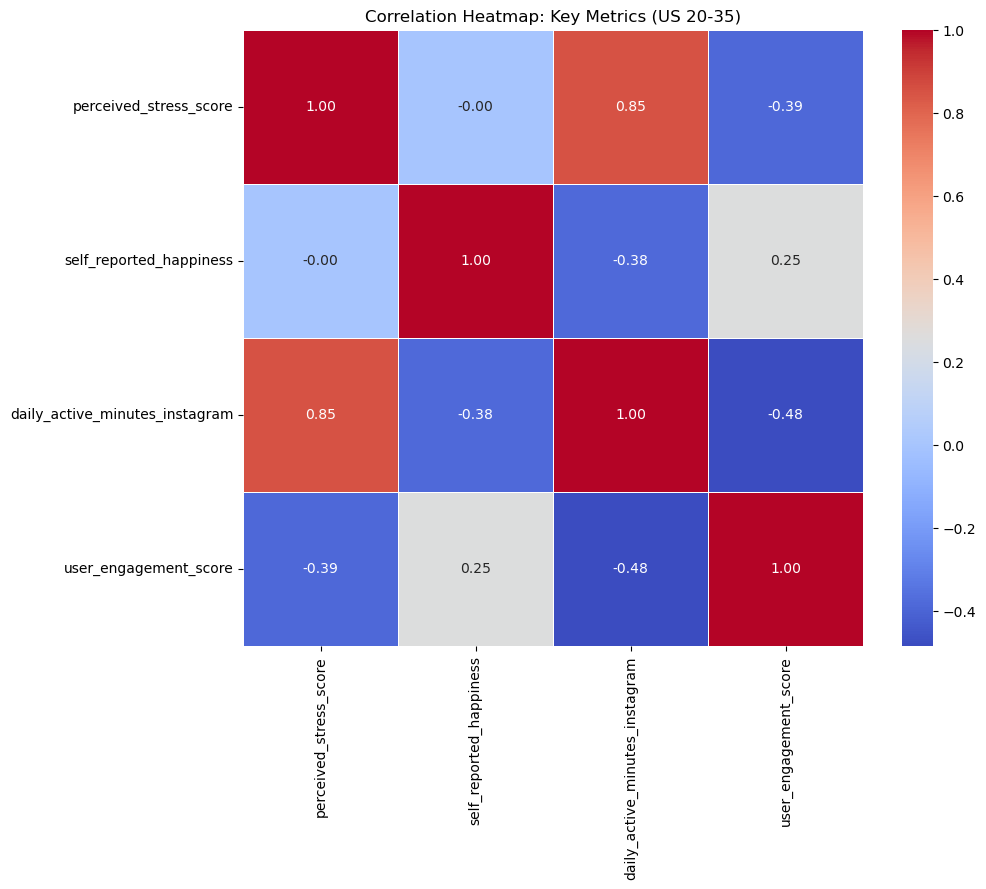

In [34]:
# Most correlated columns in a new DF which communicate any important trends...
most_corr = ['perceived_stress_score', 'self_reported_happiness',
            'daily_active_minutes_instagram', 'user_engagement_score']


# 1. Filter the original df using the mask and the list of columns
most_corr_df = df.loc[combined_mask, most_corr]

# 2. Calculate the correlation on this specific subset
corr_matrixx = most_corr_df.corr()

# 3. Create the heatmap (keeping your settings)
plt.figure(figsize=(10, 8)) # Adjusted size for better visibility
sns.heatmap(corr_matrixx, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Key Metrics (US 20-35)')
plt.savefig('heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

plt.show()